In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files

uploaded = files.upload()

for filename in uploaded.keys():
  print(f'Uploaded file: {filename}')

Saving BANK FULL.xlsx to BANK FULL.xlsx
Uploaded file: BANK FULL.xlsx


In [ ]:
df = pd.read_excel('BANK FULL.xlsx')
print("DataFrame loaded successfully. Here are the first 5 rows:")
print(df.head())

DataFrame loaded successfully. Here are the first 5 rows:
   age      job marital  education default  balance housing loan    contact  \
0   18  student  single    primary      no     1944      no   no  telephone   
1   18  student  single    unknown      no      108      no   no   cellular   
2   18  student  single    primary      no      608      no   no   cellular   
3   18  student  single    unknown      no       35      no   no  telephone   
4   18  student  single  secondary      no        5      no   no   cellular   

   day month  duration  campaign  pdays  previous poutcome    y  Int.Rate09  \
0   10   aug       122         3     -1         0  unknown   no        1.71   
1   10   aug       167         1     -1         0  unknown  yes        1.71   
2   12   aug       267         1     -1         0  unknown  yes        1.71   
3   21   aug       104         2     -1         0  unknown   no        1.71   
4   24   aug       143         2     -1         0  unknown   no        1

In [ ]:
if 'Int.R08' in df.columns:
    df = df.drop(columns=['Int.R08'])
    print("Column 'Int.R08' dropped successfully.")
else:
    print("Column 'Int.R08' not found in the DataFrame.")

print("\nDataFrame after dropping 'Int.R08' column (first 5 rows):")
print(df.head())

Column 'Int.R08' dropped successfully.

DataFrame after dropping 'Int.R08' column (first 5 rows):
   age      job marital  education default  balance housing loan    contact  \
0   18  student  single    primary      no     1944      no   no  telephone   
1   18  student  single    unknown      no      108      no   no   cellular   
2   18  student  single    primary      no      608      no   no   cellular   
3   18  student  single    unknown      no       35      no   no  telephone   
4   18  student  single  secondary      no        5      no   no   cellular   

   day month  duration  campaign  pdays  previous poutcome    y  Int.Rate09  
0   10   aug       122         3     -1         0  unknown   no        1.71  
1   10   aug       167         1     -1         0  unknown  yes        1.71  
2   12   aug       267         1     -1         0  unknown  yes        1.71  
3   21   aug       104         2     -1         0  unknown   no        1.71  
4   24   aug       143         2     

In [ ]:
columns_to_drop = ['month', 'day', 'duration', 'campaign']

for col in columns_to_drop:
    if col in df.columns:
        df = df.drop(columns=[col])
        print(f"Column '{col}' dropped successfully.")
    else:
        print(f"Column '{col}' not found in the DataFrame.")

print("\nDataFrame after dropping specified columns (first 5 rows):")
print(df.head())

Column 'month' dropped successfully.
Column 'day' dropped successfully.
Column 'duration' dropped successfully.
Column 'campaign' dropped successfully.

DataFrame after dropping specified columns (first 5 rows):
   age      job marital  education default  balance housing loan    contact  \
0   18  student  single    primary      no     1944      no   no  telephone   
1   18  student  single    unknown      no      108      no   no   cellular   
2   18  student  single    primary      no      608      no   no   cellular   
3   18  student  single    unknown      no       35      no   no  telephone   
4   18  student  single  secondary      no        5      no   no   cellular   

   pdays  previous poutcome    y  Int.Rate09  
0     -1         0  unknown   no        1.71  
1     -1         0  unknown  yes        1.71  
2     -1         0  unknown  yes        1.71  
3     -1         0  unknown   no        1.71  
4     -1         0  unknown   no        1.71  


In [ ]:
def categorize_pdays(pdays):
    if pdays == -1:
        return 'Never Contacted'
    elif 1 <= pdays <= 30:
        return 'Recent Engagement'
    elif 31 <= pdays <= 180:
        return 'Moderate Engagement'
    elif 181 <= pdays <= 365:
        return 'Low Engagement'
    elif pdays > 365:
        return 'Dormant Customers'
    else:
        return 'Unknown'

df['pdays_category'] = df['pdays'].apply(categorize_pdays)

print("\nDataFrame with new 'pdays_category' column (first 5 rows):")
print(df[['pdays', 'pdays_category']].head(20))


DataFrame with new 'pdays_category' column (first 5 rows):
    pdays       pdays_category
0      -1      Never Contacted
1      -1      Never Contacted
2      -1      Never Contacted
3      -1      Never Contacted
4      -1      Never Contacted
5      -1      Never Contacted
6      -1      Never Contacted
7      82  Moderate Engagement
8      93  Moderate Engagement
9     183       Low Engagement
10     -1      Never Contacted
11     -1      Never Contacted
12     -1      Never Contacted
13     -1      Never Contacted
14     -1      Never Contacted
15     -1      Never Contacted
16     -1      Never Contacted
17     -1      Never Contacted
18     -1      Never Contacted
19     -1      Never Contacted


In [ ]:
if 'pdays' in df.columns:
    df = df.drop(columns=['pdays'])
    print("Column 'pdays' dropped successfully.")
else:
    print("Column 'pdays' not found in the DataFrame.")

print("\nDataFrame after dropping 'pdays' column (first 5 rows):")
print(df.head())

Column 'pdays' dropped successfully.

DataFrame after dropping 'pdays' column (first 5 rows):
   age      job marital  education default  balance housing loan    contact  \
0   18  student  single    primary      no     1944      no   no  telephone   
1   18  student  single    unknown      no      108      no   no   cellular   
2   18  student  single    primary      no      608      no   no   cellular   
3   18  student  single    unknown      no       35      no   no  telephone   
4   18  student  single  secondary      no        5      no   no   cellular   

   previous poutcome    y  Int.Rate09   pdays_category  
0         0  unknown   no        1.71  Never Contacted  
1         0  unknown  yes        1.71  Never Contacted  
2         0  unknown  yes        1.71  Never Contacted  
3         0  unknown   no        1.71  Never Contacted  
4         0  unknown   no        1.71  Never Contacted  


In [ ]:
def categorize_previous(previous):
    if previous == 0:
        return 'No Previous Contact'
    elif 1 <= previous <= 5:
        return 'Low Previous Contact'
    elif 6 <= previous <= 10:
        return 'Moderate Previous Contact'
    elif 11 <= previous <= 20:
        return 'High Previous Contact'
    elif previous >= 21:
        return 'Very High Previous Contact'
    else:
        return 'Unknown'

df['previous_category'] = df['previous'].apply(categorize_previous)

print("\nDataFrame with new 'previous_category' column (first 5 rows):")
print(df[['previous', 'previous_category']].head())


DataFrame with new 'previous_category' column (first 5 rows):
   previous    previous_category
0         0  No Previous Contact
1         0  No Previous Contact
2         0  No Previous Contact
3         0  No Previous Contact
4         0  No Previous Contact


In [ ]:
if 'previous' in df.columns:
    df = df.drop(columns=['previous'])
    print("Column 'previous' dropped successfully.")
else:
    print("Column 'previous' not found in the DataFrame.")

print("\nDataFrame after dropping 'previous' column (first 5 rows):")
print(df.head(20))

Column 'previous' dropped successfully.

DataFrame after dropping 'previous' column (first 5 rows):
    age      job marital  education default  balance housing loan    contact  \
0    18  student  single    primary      no     1944      no   no  telephone   
1    18  student  single    unknown      no      108      no   no   cellular   
2    18  student  single    primary      no      608      no   no   cellular   
3    18  student  single    unknown      no       35      no   no  telephone   
4    18  student  single  secondary      no        5      no   no   cellular   
5    18  student  single    unknown      no        3      no   no   cellular   
6    18  student  single    unknown      no      108      no   no   cellular   
7    18  student  single  secondary      no      156      no   no   cellular   
8    18  student  single    primary      no      608      no   no   cellular   
9    18  student  single    unknown      no      108      no   no   cellular   
10   18  student  si

In [ ]:
# Identify categorical columns (excluding the target variable 'y' if it's categorical and not to be encoded)
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Exclude 'y' if it's in the list and you intend to handle it separately (e.g., label encoding)
if 'y' in categorical_cols:
    categorical_cols.remove('y')

print(f"Categorical columns identified for one-hot encoding: {categorical_cols}")

# Apply one-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("\nDataFrame after one-hot encoding (first 5 rows):")
print(df_encoded.head())

Categorical columns identified for one-hot encoding: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'poutcome', 'pdays_category', 'previous_category']

DataFrame after one-hot encoding (first 5 rows):
   age  balance    y  Int.Rate09  job_blue-collar  job_entrepreneur  \
0   18     1944   no        1.71            False             False   
1   18      108  yes        1.71            False             False   
2   18      608  yes        1.71            False             False   
3   18       35   no        1.71            False             False   
4   18        5   no        1.71            False             False   

   job_housemaid  job_management  job_retired  job_self-employed  ...  \
0          False           False        False              False  ...   
1          False           False        False              False  ...   
2          False           False        False              False  ...   
3          False           False        False         

In [ ]:
# Convert the target variable 'y' to numerical (0 for 'no', 1 for 'yes')
if 'y' in df_encoded.columns:
    df_encoded['y'] = df_encoded['y'].map({'no': 0, 'yes': 1})
    print("Target variable 'y' converted to numerical (0/1).")
else:
    print("Target variable 'y' not found in df_encoded.")

print("\nDataFrame after converting 'y' to numerical (first 5 rows):")
print(df_encoded.head())

Target variable 'y' converted to numerical (0/1).

DataFrame after converting 'y' to numerical (first 5 rows):
   age  balance  y  Int.Rate09  job_blue-collar  job_entrepreneur  \
0   18     1944  0        1.71            False             False   
1   18      108  1        1.71            False             False   
2   18      608  1        1.71            False             False   
3   18       35  0        1.71            False             False   
4   18        5  0        1.71            False             False   

   job_housemaid  job_management  job_retired  job_self-employed  ...  \
0          False           False        False              False  ...   
1          False           False        False              False  ...   
2          False           False        False              False  ...   
3          False           False        False              False  ...   
4          False           False        False              False  ...   

   poutcome_success  poutcome_unkno

In [ ]:
# Identify boolean columns
boolean_cols = df_encoded.select_dtypes(include='bool').columns

# Convert boolean columns to integers (True to 1, False to 0)
for col in boolean_cols:
    df_encoded[col] = df_encoded[col].astype(int)

print("\nDataFrame after converting boolean columns to integers (first 5 rows):")
print(df_encoded.head())


DataFrame after converting boolean columns to integers (first 5 rows):
   age  balance  y  Int.Rate09  job_blue-collar  job_entrepreneur  \
0   18     1944  0        1.71                0                 0   
1   18      108  1        1.71                0                 0   
2   18      608  1        1.71                0                 0   
3   18       35  0        1.71                0                 0   
4   18        5  0        1.71                0                 0   

   job_housemaid  job_management  job_retired  job_self-employed  ...  \
0              0               0            0                  0  ...   
1              0               0            0                  0  ...   
2              0               0            0                  0  ...   
3              0               0            0                  0  ...   
4              0               0            0                  0  ...   

   poutcome_success  poutcome_unknown  pdays_category_Low Engagement  \
0 

In [ ]:
print(df_encoded.columns.tolist())

['age', 'balance', 'y', 'Int.Rate09', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'job_unknown', 'marital_married', 'marital_single', 'education_secondary', 'education_tertiary', 'education_unknown', 'default_yes', 'housing_yes', 'loan_yes', 'contact_telephone', 'contact_unknown', 'poutcome_other', 'poutcome_success', 'poutcome_unknown', 'pdays_category_Low Engagement', 'pdays_category_Moderate Engagement', 'pdays_category_Never Contacted', 'pdays_category_Recent Engagement', 'previous_category_Low Previous Contact', 'previous_category_Moderate Previous Contact', 'previous_category_No Previous Contact', 'previous_category_Very High Previous Contact']


In [ ]:
from sklearn.preprocessing import StandardScaler

# Separate features (X) from the target variable (y)
X = df_encoded.drop('y', axis=1)
y = df_encoded['y']

# Identify numerical columns for scaling (excluding 'y' as it's the target)
numerical_cols = ['age', 'balance', 'Int.Rate09']

# Initialize the StandardScaler
scaler = StandardScaler()

# Apply StandardScaler to the numerical columns in X
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

print("Features (X) after scaling numerical columns (first 5 rows):")
print(X.head())

Features (X) after scaling numerical columns (first 5 rows):
        age   balance  Int.Rate09  job_blue-collar  job_entrepreneur  \
0 -2.159994  0.191060   -1.042919                0                 0   
1 -2.159994 -0.411948   -1.042919                0                 0   
2 -2.159994 -0.247730   -1.042919                0                 0   
3 -2.159994 -0.435924   -1.042919                0                 0   
4 -2.159994 -0.445777   -1.042919                0                 0   

   job_housemaid  job_management  job_retired  job_self-employed  \
0              0               0            0                  0   
1              0               0            0                  0   
2              0               0            0                  0   
3              0               0            0                  0   
4              0               0            0                  0   

   job_services  ...  poutcome_success  poutcome_unknown  \
0             0  ...                 

### Finding the Optimal Number of Clusters using the Elbow Method

The Elbow Method is a heuristic used in determining the number of clusters in a dataset. The idea is to run k-means clustering for a range of k values (e.g., from 1 to 10) and for each k, we calculate the sum of squared distances (inertia) between data points and their assigned cluster centroid. The 'elbow' point in the plot of inertia versus the number of clusters is usually considered to be an indicator of the optimal number of clusters.

In [ ]:
from sklearn.cluster import KMeans

# Initialize a list to store the inertia values
inertia = []

# Define the range of cluster numbers to test
k_range = range(1, 11) # Test from 1 to 10 clusters

# Calculate inertia for each k
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # n_init is set to suppress warning
    kmeans.fit(X) # Fit KMeans on the scaled features
    inertia.append(kmeans.inertia_)

# Display the inertia values
print("Inertia values for k from 1 to 10:")
for k, val in zip(k_range, inertia):
    print(f"k={k}: {val:.2f}")

Inertia values for k from 1 to 10:
k=1: 279445.70
k=2: 243918.26
k=3: 215941.27
k=4: 195464.66
k=5: 174986.01
k=6: 164555.65
k=7: 157502.08
k=8: 152558.99
k=9: 145841.10
k=10: 142179.12


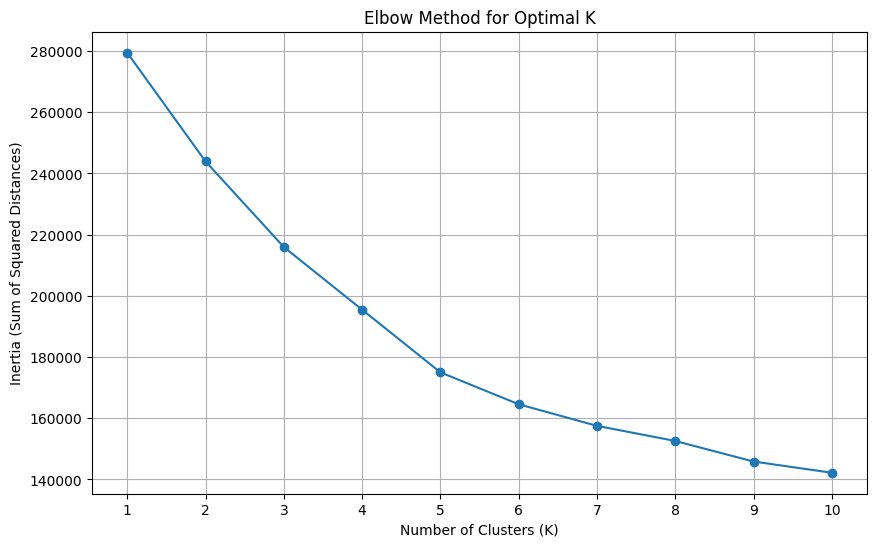

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the Elbow Method results
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Sum of Squared Distances)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

### Applying K-Means Clustering

In [ ]:
# Apply K-Means clustering with the chosen number of clusters (e.g., 4)
k_optimal = 4
kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)

# Fit KMeans on the scaled features and get cluster labels
cluster_labels = kmeans.fit_predict(X)

# Add the cluster labels to the original (encoded) DataFrame
df_encoded['Cluster'] = cluster_labels

print(f"K-Means clustering applied with {k_optimal} clusters.")
print("First 5 rows of df_encoded with new 'Cluster' column:")
print(df_encoded.head())

K-Means clustering applied with 4 clusters.
First 5 rows of df_encoded with new 'Cluster' column:
   age  balance  y  Int.Rate09  job_blue-collar  job_entrepreneur  \
0   18     1944  0        1.71                0                 0   
1   18      108  1        1.71                0                 0   
2   18      608  1        1.71                0                 0   
3   18       35  0        1.71                0                 0   
4   18        5  0        1.71                0                 0   

   job_housemaid  job_management  job_retired  job_self-employed  ...  \
0              0               0            0                  0  ...   
1              0               0            0                  0  ...   
2              0               0            0                  0  ...   
3              0               0            0                  0  ...   
4              0               0            0                  0  ...   

   poutcome_unknown  pdays_category_Low Engageme

### Analyzing Cluster Characteristics

To understand the characteristics of each cluster, we can examine the mean values of features within each cluster. This helps in profiling and interpreting what each cluster represents.

In [ ]:
# Analyze the mean of features for each cluster
cluster_analysis = df_encoded.groupby('Cluster').mean()

print("Mean feature values for each cluster:")
print(cluster_analysis)


Mean feature values for each cluster:
               age       balance         y  Int.Rate09  job_blue-collar  \
Cluster                                                                   
0        52.279302   1183.935751  0.112761    1.919820         0.205953   
1        34.034735    858.742435  0.106623    1.954029         0.228354   
2        38.527597    972.766234  0.150568    2.533408         0.208604   
3        43.430116  14117.054054  0.148263    1.941992         0.136680   

         job_entrepreneur  job_housemaid  job_management  job_retired  \
Cluster                                                                 
0                0.037975       0.048854        0.195689     0.133972   
1                0.029942       0.017071        0.212835     0.001780   
2                0.030303       0.015557        0.203057     0.026245   
3                0.040154       0.028571        0.335135     0.056371   

         job_self-employed  ...  poutcome_success  poutcome_unknown  \
C

### Evaluating Clustering Quality using Silhouette Score

The Silhouette Score is a metric used to calculate the goodness of a clustering technique. Its value ranges from -1 to 1. A score of 1 indicates that the clusters are well separated, a score of 0 indicates overlapping clusters, and a score of -1 indicates that data points have been assigned to the wrong clusters.

We will calculate the Silhouette score for each number of clusters within our `k_range` (from 2 to 10, as it's not defined for a single cluster) and plot the results.

In [ ]:
from sklearn.metrics import silhouette_score

# Initialize a list to store Silhouette scores
silhouette_scores = []

# Define the range of cluster numbers to test (Silhouette requires at least 2 clusters)
k_range_silhouette = range(2, 11)

# Calculate Silhouette score for each k
for k in k_range_silhouette:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X)
    score = silhouette_score(X, cluster_labels)
    silhouette_scores.append(score)

# Display the Silhouette scores
print("Silhouette scores for k from 2 to 10:")
for k, score in zip(k_range_silhouette, silhouette_scores):
    print(f"k={k}: {score:.2f}")

Silhouette scores for k from 2 to 10:
k=2: 0.14
k=3: 0.16
k=4: 0.15
k=5: 0.17
k=6: 0.14
k=7: 0.13
k=8: 0.13
k=9: 0.13
k=10: 0.12


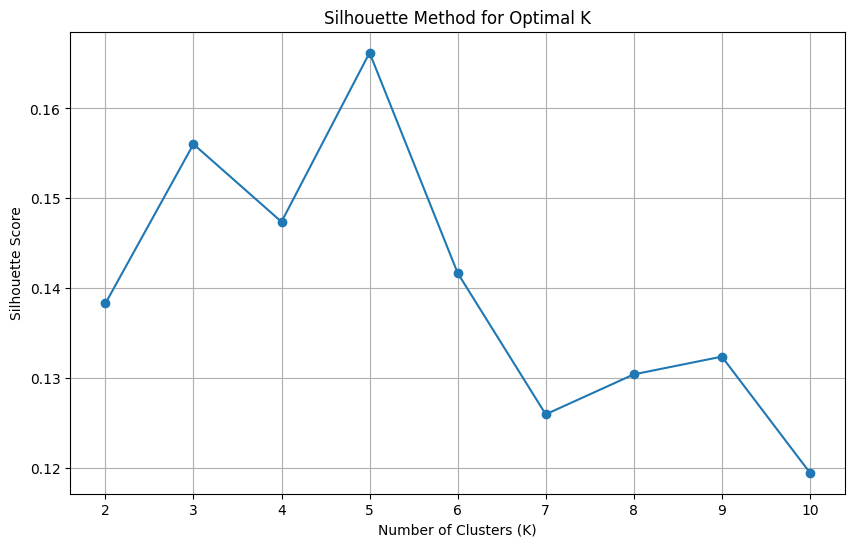

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the Silhouette Method results
plt.figure(figsize=(10, 6))
plt.plot(k_range_silhouette, silhouette_scores, marker='o')
plt.title('Silhouette Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(k_range_silhouette)
plt.grid(True)
plt.show()

### Re-applying K-Means Clustering with 5 Clusters (based on Silhouette Score)

In [ ]:
# Apply K-Means clustering with the new optimal number of clusters (5)
k_optimal_silhouette = 5
kmeans_5 = KMeans(n_clusters=k_optimal_silhouette, random_state=42, n_init=10)

# Fit KMeans on the scaled features and get cluster labels
cluster_labels_5 = kmeans_5.fit_predict(X)

# Add the new cluster labels to the original (encoded) DataFrame
df_encoded['Cluster_5'] = cluster_labels_5

print(f"K-Means clustering re-applied with {k_optimal_silhouette} clusters.")
print("First 5 rows of df_encoded with new 'Cluster_5' column:")
print(df_encoded.head())

K-Means clustering re-applied with 5 clusters.
First 5 rows of df_encoded with new 'Cluster_5' column:
   age  balance  y  Int.Rate09  job_blue-collar  job_entrepreneur  \
0   18     1944  0        1.71                0                 0   
1   18      108  1        1.71                0                 0   
2   18      608  1        1.71                0                 0   
3   18       35  0        1.71                0                 0   
4   18        5  0        1.71                0                 0   

   job_housemaid  job_management  job_retired  job_self-employed  ...  \
0              0               0            0                  0  ...   
1              0               0            0                  0  ...   
2              0               0            0                  0  ...   
3              0               0            0                  0  ...   
4              0               0            0                  0  ...   

   pdays_category_Low Engagement  pdays_cat

### Analyzing Characteristics of the 5 Clusters

Now, let's examine the mean values of features within these 5 clusters to understand their distinct characteristics.

In [ ]:
# Calculate the proportion of customers in each cluster
cluster_proportions = df_encoded['Cluster_5'].value_counts(normalize=True).sort_index()

# Calculate the average age for each cluster
cluster_avg_age = df_encoded.groupby('Cluster_5')['age'].mean()

# Calculate the subscription rate (mean of 'y') for each cluster
cluster_subscription_rate = df_encoded.groupby('Cluster_5')['y'].mean()

print("\nProportion of customers in each cluster:")
print(cluster_proportions)

print("\nAverage age for each cluster:")
print(cluster_avg_age)

print("\nSubscription rate (mean of 'y') for each cluster:")
print(cluster_subscription_rate)


Proportion of customers in each cluster:
Cluster_5
0    0.139170
1    0.450753
2    0.295791
3    0.024065
4    0.090221
Name: proportion, dtype: float64

Average age for each cluster:
Cluster_5
0    38.982994
1    34.094558
2    52.262619
3    43.501838
4    40.312577
Name: age, dtype: float64

Subscription rate (mean of 'y') for each cluster:
Cluster_5
0    0.226637
1    0.087885
2    0.095940
3    0.150735
4    0.153224
Name: y, dtype: float64


In [ ]:
# Calculate the average balance for each cluster
cluster_avg_balance = df_encoded.groupby('Cluster_5')['balance'].mean()

# Combine all summary statistics into a single DataFrame
cluster_summary = pd.DataFrame({
    'Proportion': cluster_proportions,
    'Average Age': cluster_avg_age,
    'Average Balance': cluster_avg_balance,
    'Subscription Rate': cluster_subscription_rate
})

# Display the summary table
print("\nSummary of Clusters:")
display(cluster_summary.round(2))


Summary of Clusters:


,Proportion,Average Age,Average Balance,Subscription Rate
Cluster_5,,,,
0,0.14,38.98,1256.67,0.23
1,0.45,34.09,842.31,0.09
2,0.30,52.26,1192.91,0.10
3,0.02,43.50,15247.56,0.15
4,0.09,40.31,974.52,0.15


/tmp/ipykernel_9599/3375445506.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_subscription_rate.index, y=cluster_subscription_rate.values, palette='viridis')


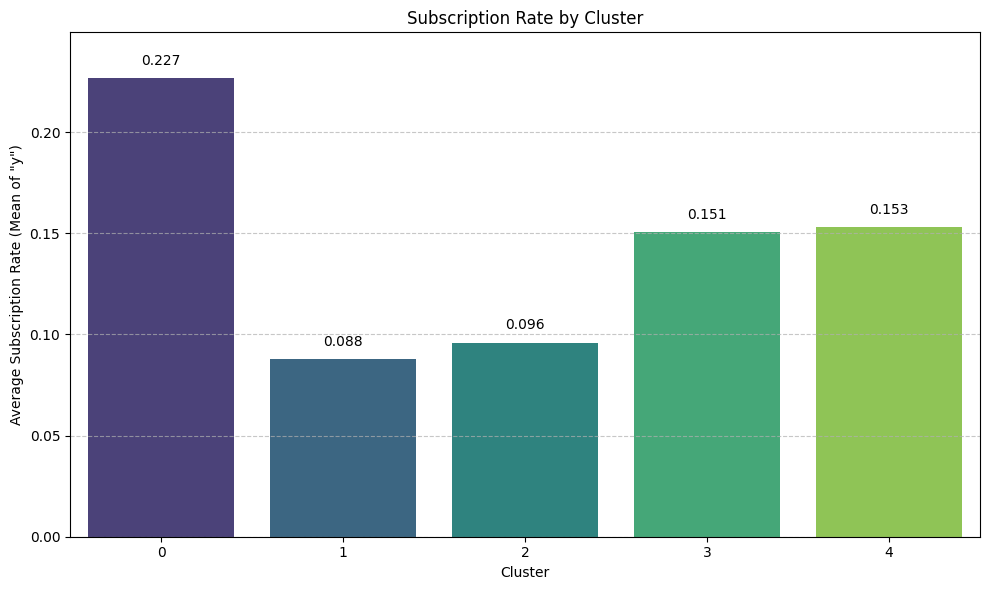

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a bar chart for subscription rates by cluster
plt.figure(figsize=(10, 6))
sns.barplot(x=cluster_subscription_rate.index, y=cluster_subscription_rate.values, palette='viridis')
plt.title('Subscription Rate by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Average Subscription Rate (Mean of "y")')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, max(cluster_subscription_rate.values) * 1.1) # Set y-axis limit slightly above max value

# Add exact values on top of the bars
for index, value in enumerate(cluster_subscription_rate.values):
    plt.text(index, value + 0.005, f'{value:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [ ]:
# Analyze the mean of features for each of the 5 clusters
cluster_analysis_5 = df_encoded.groupby('Cluster_5').mean()

print("Mean feature values for each of the 5 clusters:")
print(cluster_analysis_5)

Mean feature values for each of the 5 clusters:
                 age       balance         y  Int.Rate09  job_blue-collar  \
Cluster_5                                                                   
0          38.982994   1256.674507  0.226637    1.990445         0.215035   
1          34.094558    842.314294  0.087885    1.971242         0.239021   
2          52.262619   1192.907650  0.095940    1.919535         0.208181   
3          43.501838  15247.559743  0.150735    1.944283         0.123162   
4          40.312577    974.519245  0.153224    2.851108         0.144643   

           job_entrepreneur  job_housemaid  job_management  job_retired  \
Cluster_5                                                                 
0                  0.028290       0.016370        0.227750     0.019390   
1                  0.030423       0.017322        0.206732     0.001914   
2                  0.038585       0.050101        0.191879     0.136319   
3                  0.044118       0.0

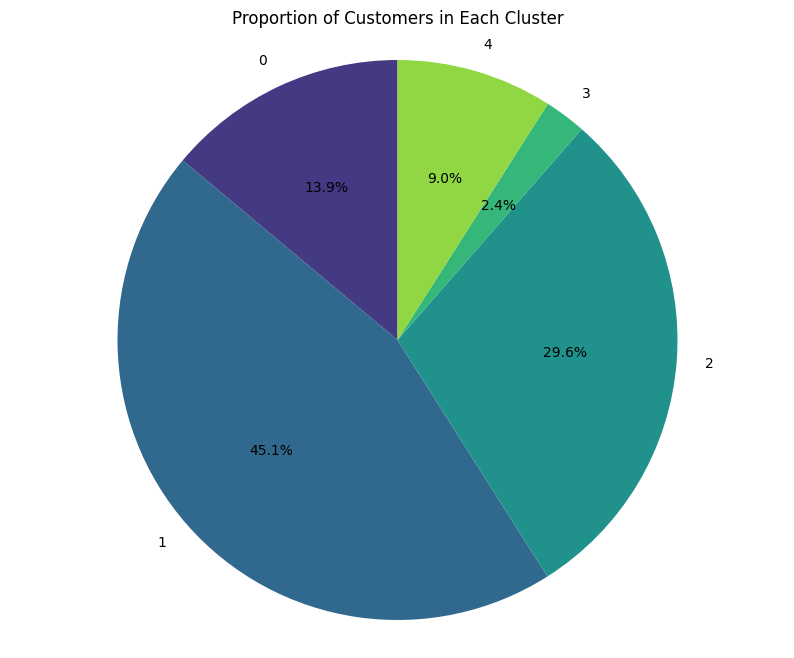

In [ ]:
import matplotlib.pyplot as plt

# Create a pie chart for cluster proportions
plt.figure(figsize=(10, 8))
plt.pie(cluster_proportions, labels=cluster_proportions.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('viridis', n_colors=len(cluster_proportions)))
plt.title('Proportion of Customers in Each Cluster')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

### Visualizing the Clusters with PCA

To visualize high-dimensional clusters, we first need to reduce the dimensionality of the data. Principal Component Analysis (PCA) is a popular technique for this. We will reduce the data to 2 principal components and then plot the clusters in this 2D space, coloring each point by its assigned cluster.

In [ ]:
from sklearn.decomposition import PCA

# Apply PCA to reduce to 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Create a DataFrame for the PCA results
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])

# Add the cluster labels to the PCA DataFrame
pca_df['Cluster'] = df_encoded['Cluster_5']

print("First 5 rows of PCA components with cluster labels:")
print(pca_df.head())

First 5 rows of PCA components with cluster labels:
        PC1       PC2  Cluster
0 -1.009659 -1.655234        1
1 -1.309940 -1.866356        1
2 -1.243369 -1.821685        1
3 -1.290798 -1.849734        1
4 -1.404000 -1.899395        1


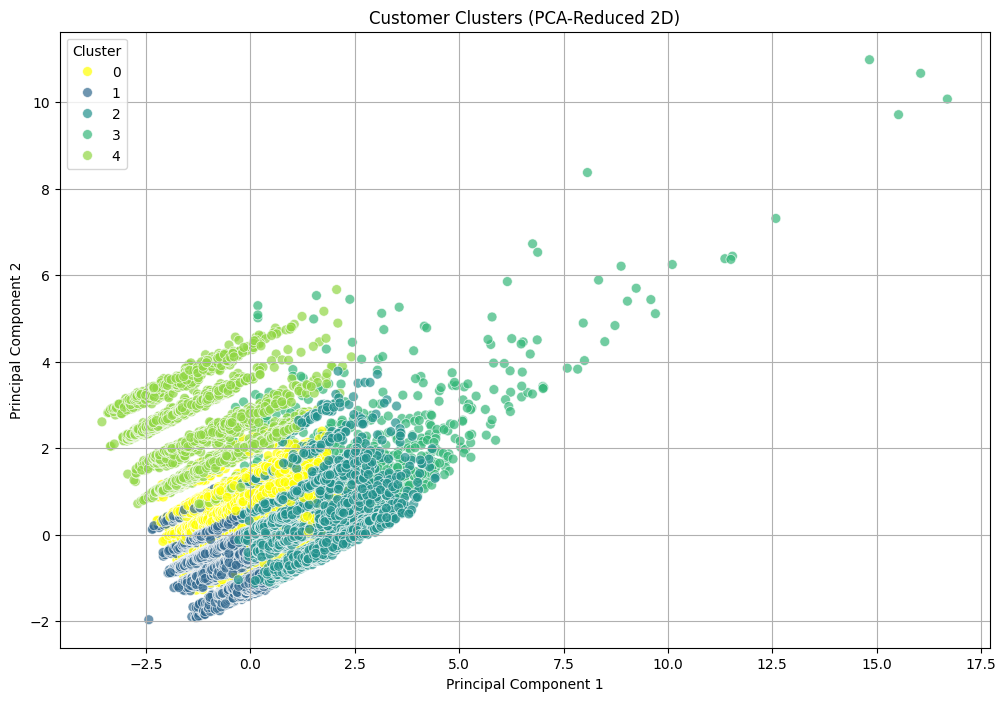

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the 'viridis' palette colors for 5 clusters
viridis_colors = sns.color_palette('viridis', n_colors=5)

# Define a custom color palette with yellow for Cluster 0
custom_palette = {
    0: 'yellow', # Cluster 0 in yellow
    1: viridis_colors[1],
    2: viridis_colors[2],
    3: viridis_colors[3],
    4: viridis_colors[4]
}

# Plot the clusters using the PCA components with the custom palette
plt.figure(figsize=(12, 8))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=pca_df, palette=custom_palette, s=50, alpha=0.7)
plt.title('Customer Clusters (PCA-Reduced 2D)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

### Age Distribution by Cluster

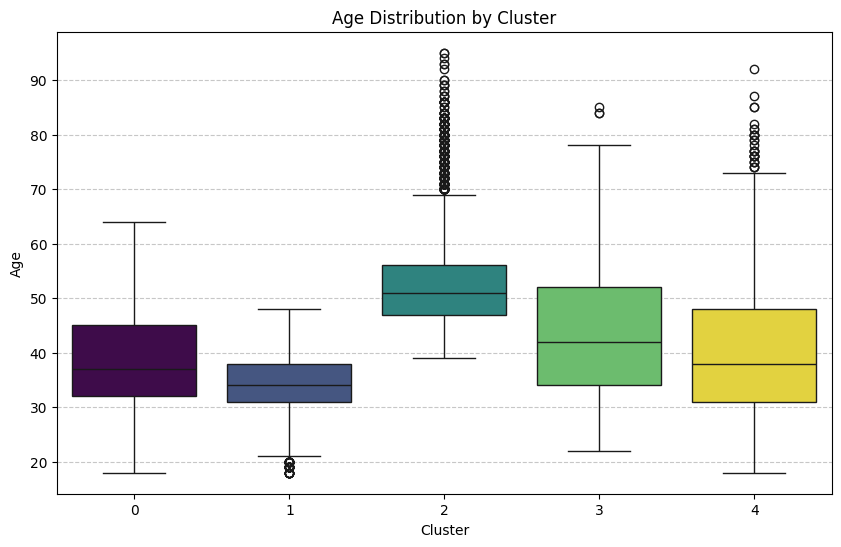

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Cluster_5', y='age', data=df_encoded, palette='viridis', hue='Cluster_5', legend=False)
plt.title('Age Distribution by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Age')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Balance Distribution by Cluster

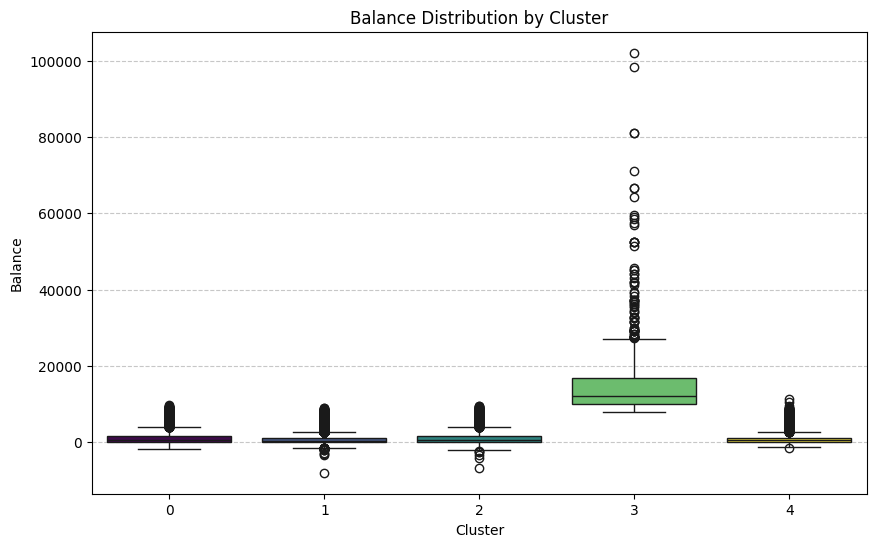

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Cluster_5', y='balance', data=df_encoded, palette='viridis', hue='Cluster_5', legend=False)
plt.title('Balance Distribution by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Balance')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Average Balance by Cluster

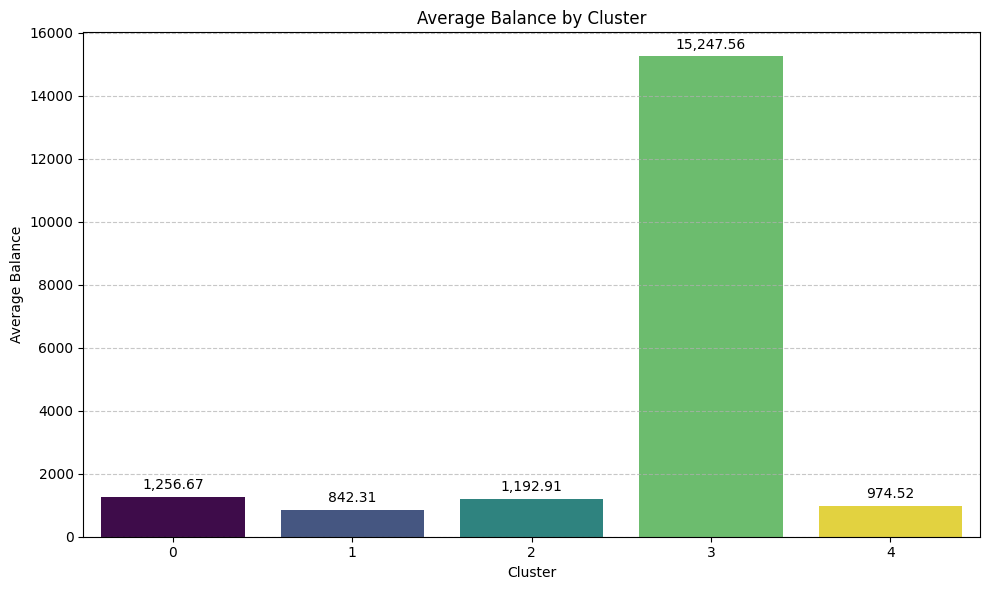

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x=cluster_avg_balance.index, y=cluster_avg_balance.values, palette='viridis', hue=cluster_avg_balance.index, legend=False)
plt.title('Average Balance by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Average Balance')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add exact values on top of the bars
for index, value in enumerate(cluster_avg_balance.values):
    plt.text(index, value + (max(cluster_avg_balance.values) * 0.01), f'{value:,.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# # End of Analysis

This notebook contains all data preprocessing, feature engineering, Clustering, model evaluation, and interpretability analyses used in this project.

Generative AI tools were used to assist with code development, debugging, and documentation. All code was reviewed, tested, modified where necessary, and executed by the author.